## Лабораторная работа №1
### Компьютерное зрение

**Выполнил:** Изгородин Илья Юрьевич  
**Группа:** ФИТ-232  
**Факультет:** ФИТиКС ОмГТУ  

*Омск, 2026*

## Подготовка окружения

Перед началом выполнения работы устанавливаю и импотрирую библиотеки, необходимые для поставленных заданий

In [21]:
!pip install matplotlib==3.10.8 numpy==2.4.2 opencv-python==4.13.0.92 opencv-contrib-python==4.13.0.92

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

## Загрузка изображения

Загрузка изображения через URL не прошла, wiki блокирует запрос, поэтому использую загрузку с локального хранилища, ведь главная суть работы - не обработка запросов, а обработка изображения

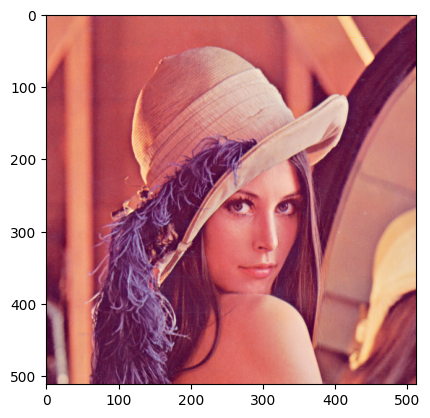

In [4]:
img = cv2.cvtColor(cv2.imread("Lenna.png"), cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

# Задание 1 Чтение и отображение

Для удобства отображения изображения в дальнейшем оглашаю функцию, способную выводить изображение без лишних осей и рамок

In [5]:
def imsh(img):
    fig = plt.figure(frameon=False)
    ax = plt.Axes(fig, [0., 0., 1., 1.])
    ax.set_axis_off()
    fig.add_axes(ax)
    ax.imshow(img)
    plt.show()

Для разделения каналов оглашаю функцию, которая извлекает из изображения только указанный канал и возвращает канал изображения в формате массива.

In [6]:
def ch_extract(img, channel):
    ch_img = np.zeros_like(img)
    ch_img[:, :, channel] = img[:, :, channel]
    return ch_img

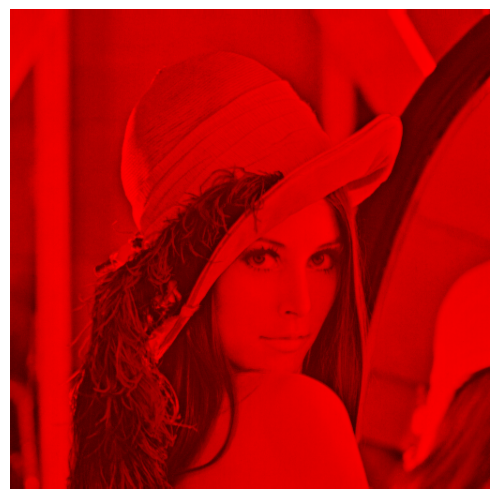

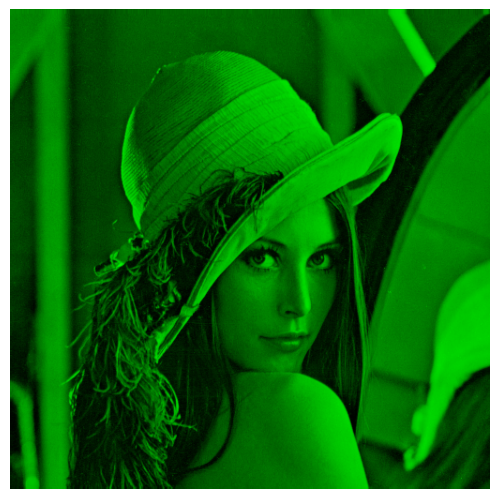

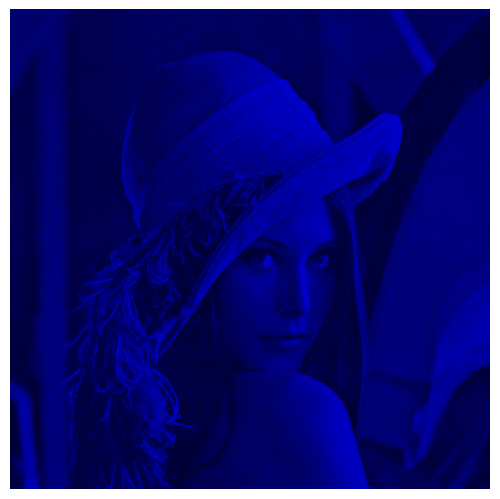

In [7]:
for i in range(3):
    imsh(ch_extract(img, i))

Для вывода гистограмм каждого канала применяю встроенный функционал matplotlib, отправляя на подсчёт каждый канал поочерёдно

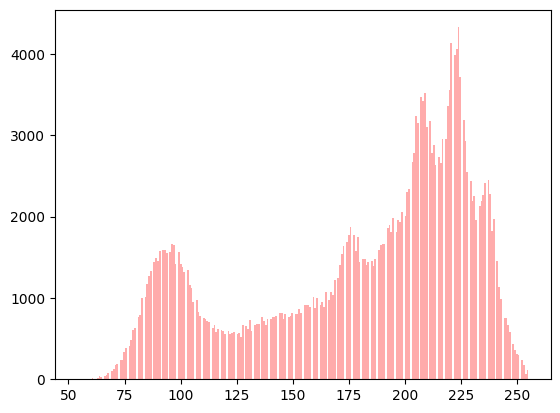

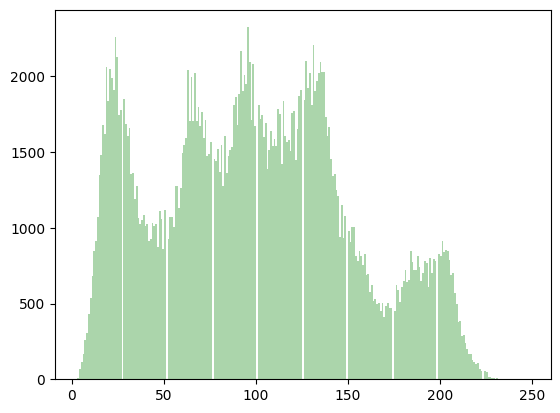

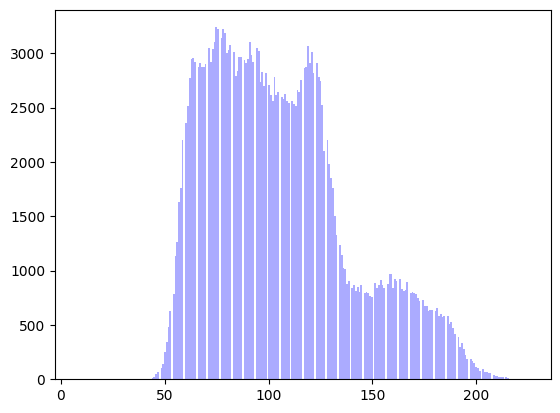

In [8]:
colors = {0: 'red', 1: 'green', 2: 'blue'}

for i in range(3):
    plt.hist(img[:, :, i].ravel(), bins=255, color=colors[i], alpha=0.33)
    plt.show()

Для удобства анализа объединяю гистограммы на один график

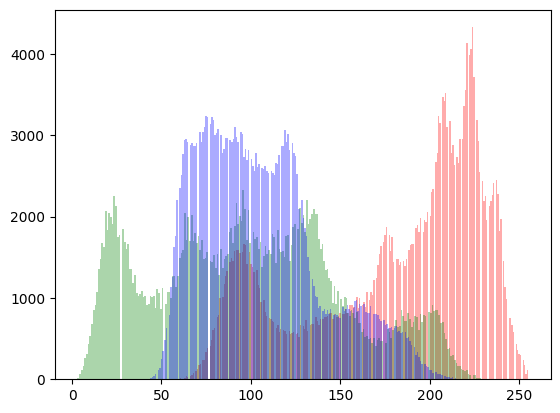

In [9]:
for i in range(3):
    plt.hist(img[:, :, i].ravel(), bins=255, color=colors[i], alpha=0.33)

plt.show()

# Задание 2 Добавление границы

Для создания рамки у изображения создана функция с выбором метода заполнения рамки.

Логика работы методов:
- Константный метод:
    - Создаем большое черное полотно
    - Заливаем всё заданным цветом
    - В центр вставляем оригинал

- Метод отражения:
    - Вставляем оригинал в центр
    - Верхняя граница - зеркальное отражение верхней части оригинала (идет снизу вверх)
    - Нижняя граница - зеркальное отражение нижней части оригинала (идет сверху вниз)
    - Левая граница - копируем правую часть уже заполненной области (зеркально)
    - Правая граница - копируем левую часть уже заполненной области (зеркально)
    - Углы - зеркальное отражение противоположных углов

- Метод дублирования:
    - Вставляем оригинал в центр
    - Верхняя граница - копия первой строки оригинала
    - Нижняя граница - копия последней строки оригинала
    - Левая граница - копия первого столбца оригинала
    - Правая граница - копия последнего столбца оригинала
    - Углы - копии угловых пикселей оригинала

In [10]:
def add_border(img, border_size, method='const', color=(0,0,0)):
    h, w = img.shape[:2]
    new_img = np.zeros((h+2*border_size, w+2*border_size, 3), dtype=np.uint8)
    new_img[border_size:border_size+h, border_size:border_size+w] = img
    
    if method == 'const':
        new_img[:, :] = color
        new_img[border_size:border_size+h, border_size:border_size+w] = img
        
    elif method == 'reflect':
        for i in range(border_size):
            new_img[i, border_size:border_size+w] = img[border_size-i-1, :]
            new_img[border_size+h+i, border_size:border_size+w] = img[h-i-1, :]

        for i in range(border_size):
            new_img[border_size:border_size+h, i] = new_img[border_size:border_size+h, 2*border_size-i-1]
            new_img[border_size:border_size+h, border_size+w+i] = new_img[border_size:border_size+h, border_size+w-i-1]

        for i in range(border_size):
            for j in range(border_size):
                new_img[i, j] = new_img[2*border_size-i-1, 2*border_size-j-1]
                new_img[i, border_size+w+j] = new_img[2*border_size-i-1, border_size+w-j-1]

        for i in range(border_size):
            for j in range(border_size):
                new_img[border_size+h+i, j] = new_img[border_size+h-i-1, 2*border_size-j-1]
                new_img[border_size+h+i, border_size+w+j] = new_img[border_size+h-i-1, border_size+w-j-1]
                
    elif method == 'replicate':
        for i in range(border_size):
            new_img[i, border_size:border_size+w] = img[0, :]
            new_img[border_size+h+i, border_size:border_size+w] = img[h-1, :]

        for i in range(border_size):
            new_img[border_size:border_size+h, i] = img[:, 0]
            new_img[border_size:border_size+h, border_size+w+i] = img[:, w-1]

        new_img[:border_size, :border_size] = img[0, 0]
        new_img[:border_size, border_size+w:] = img[0, w-1]
        new_img[border_size+h:, :border_size] = img[h-1, 0]
        new_img[border_size+h:, border_size+w:] = img[h-1, w-1]
    
    return new_img

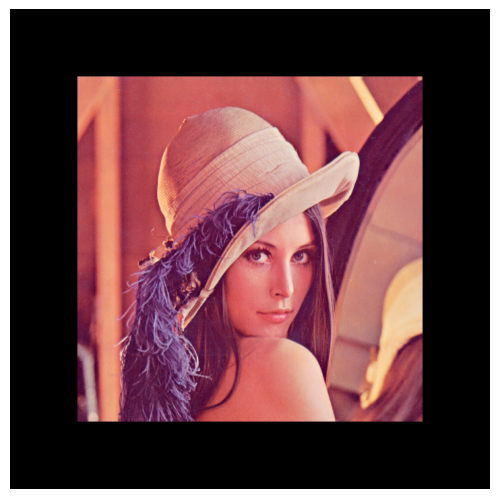

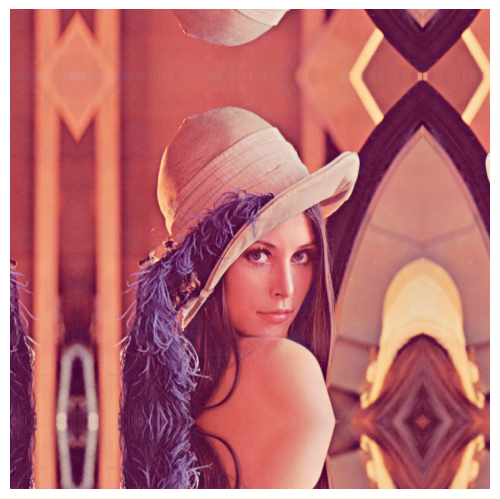

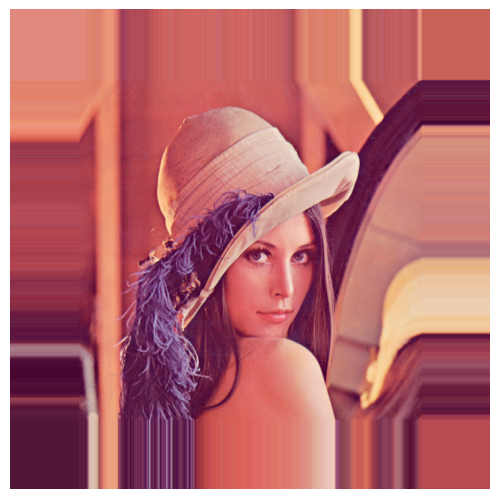

In [11]:
for m in ['const', 'reflect', 'replicate']:
    imsh(add_border(img, 100, m))

# Задание 3 RGB  -> GRAY

Для перевода RGB в ЧБ созданы три функции (последняя - просто обёртка для единообразия), переводящие три канала с разными значениями в те же три канала, но с равным значением, полученным разными способами

In [12]:
def rgb2gray_mean(img):
    gray = np.mean(img, axis=2).astype(np.uint8)
    return np.stack([gray, gray, gray], axis=2)

def rgb2gray_weighted(img):
    gray = (0.299 * img[:,:,0] + 0.587 * img[:,:,1] + 0.114 * img[:,:,2]).astype(np.uint8)
    return np.stack([gray, gray, gray], axis=2)

def rgb2gray_cv(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

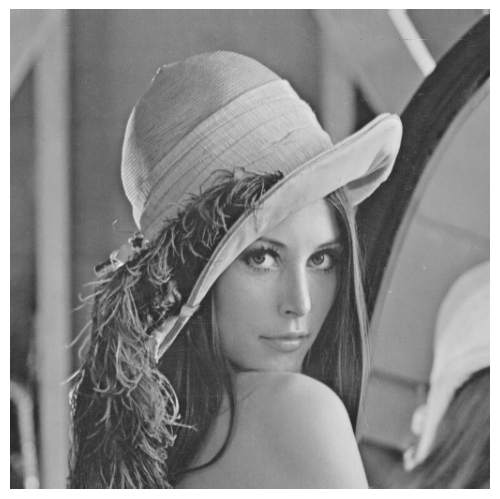

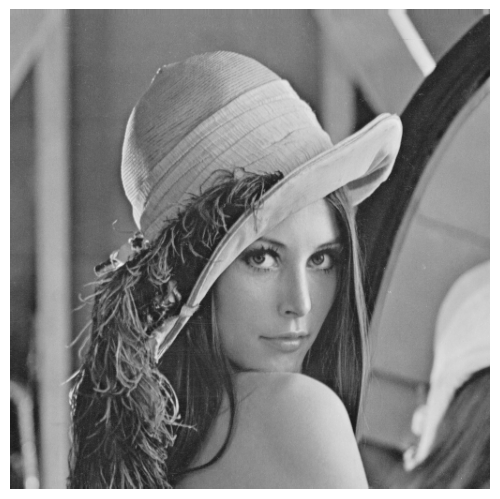

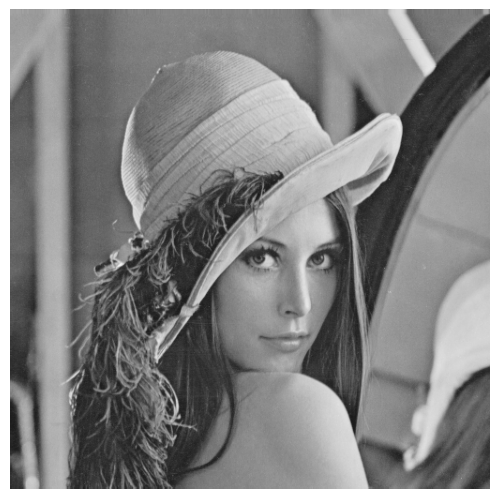

In [13]:
for f in [rgb2gray_mean, rgb2gray_weighted, rgb2gray_cv]:
    imsh(f(img))

# Задание 4 Манипуляция с пикселями

Для изменения канала в несколько раз создана функция, в которой во избежание переполнения происходит конвертация типов int8->float32, а после преобразования канала типы конвертируются обратно, получая RGB изображение с изменённым каналом

P.S. Сменил `np.clip` на `cv2.normalize` после слов про `clip` на лекции

In [14]:
def shift_image(img, channel, factor):
    img = img.astype(np.float32)
    img[:,:,channel] *= factor
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
    return img.astype(np.uint8)

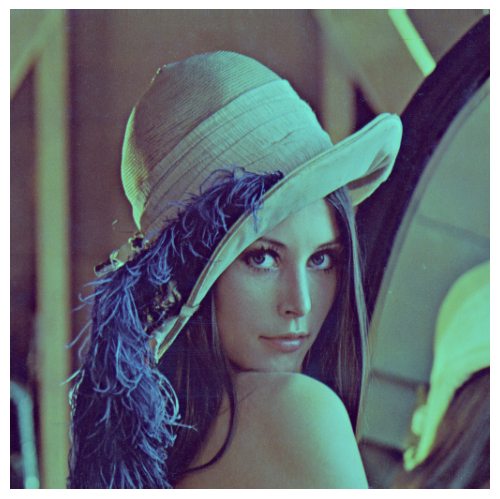

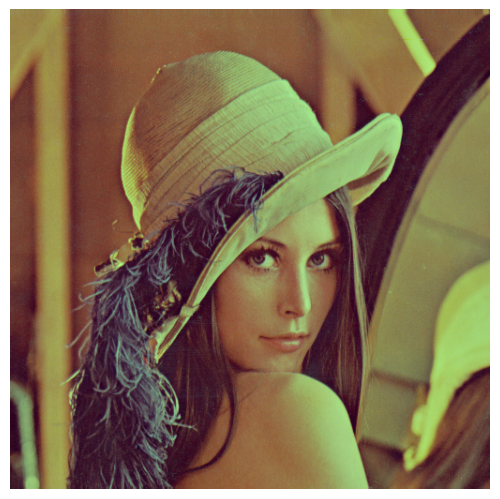

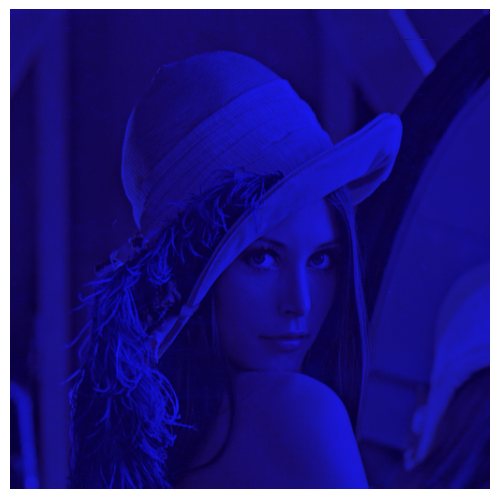

In [15]:
imsh(shift_image(img, 0, 0.5))
imsh(shift_image(img, 1, 1.5))
imsh(shift_image(img, 2, 10))

Для извлечения фрагмента прямоугольной формы из изображения создана функция, возвращающая фрагмент и изображение, без вырезанного фрагмента (на месте выреза заполнение константным цветом)

In [16]:
def cut_rect(img, x, y, w, h, color=(0,0,0)):
    img = img.copy()
    rect = img[y:y+h, x:x+w].copy()
    img[y:y+h, x:x+w] = color
    return rect, img

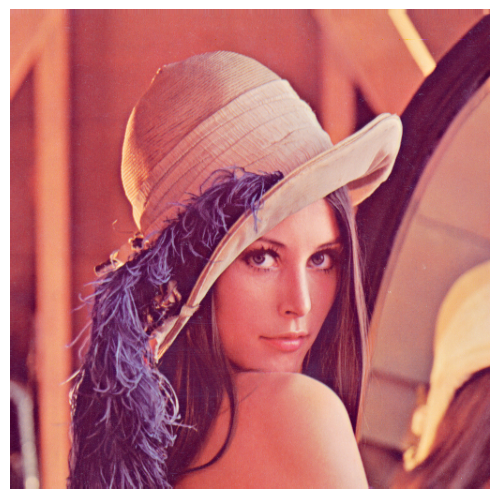

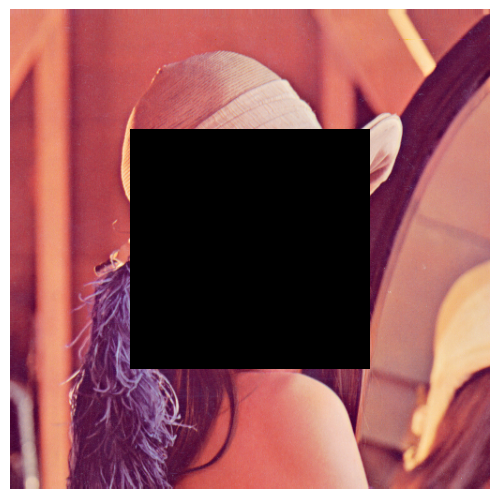

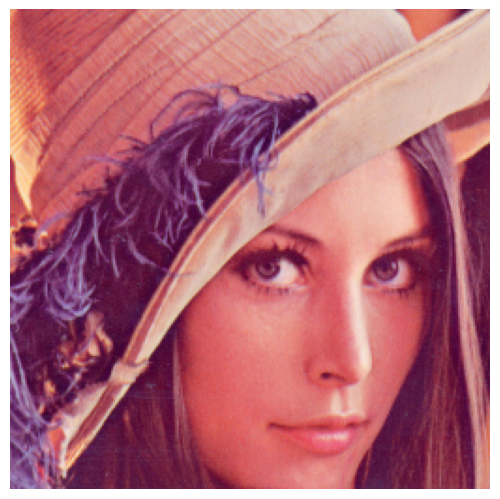

In [17]:
rect, new_img = cut_rect(img, 128, 128, 256, 256)

for p in [img, new_img, rect]:
    imsh(p)

# Задание 5 RGB -> HSV

Для конвертации RGB в HSV оглашены функции-обёртки, над существующим функционалом библиотеки cv. Для демонстрации разницы форматов записи цвета применяется функция, разработанная под RGB, но на HSV формат

In [18]:
def rgb2hsv(img):
    return cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

def hsv2rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_HSV2RGB)

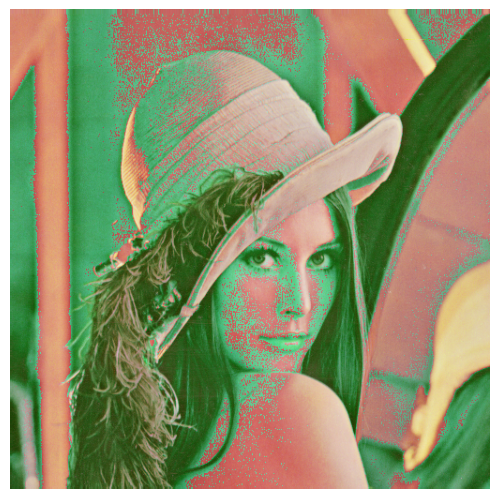

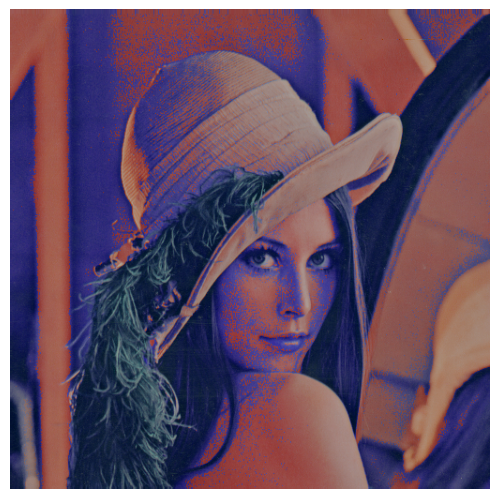

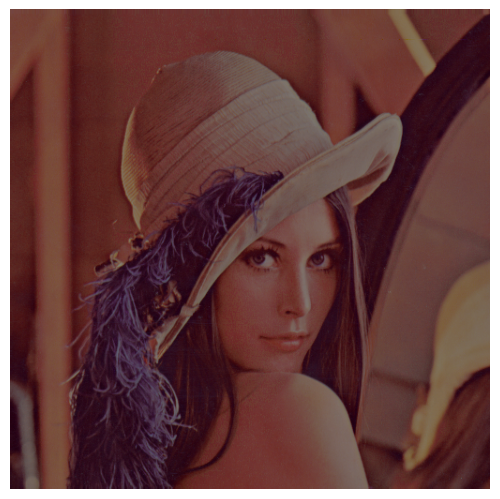

In [19]:
hsv_img = rgb2hsv(img)

imsh(hsv2rgb(shift_image(hsv_img, 0, 1.5)))
imsh(hsv2rgb(shift_image(hsv_img, 1, 1.5)))
imsh(hsv2rgb(shift_image(hsv_img, 2, 0.5)))

## Вывод

В ходе лабораторной работы я ознакомился с обработкой изображений в формате RGB в среде Python 3, с распространёнными библиотеками matplotlib, numpy и cv2. Я разработал несколько функций для преобразования изображений, а так же на примере с демонстрацией закрепил полученные знания.